In [1]:
from pyspark.sql import SparkSession

# It's good practice to wrap your main logic in a function
def main():
    # Initialize Spark Session
    spark = SparkSession.builder \
        .appName("KSRTC_Data_Collection") \
        .getOrCreate()

    # Define base path to avoid repeating long strings
    base_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\DATASETS\\"

    # Step 1 - Load Bus Schedule (CSV)
    # Using the same dataset for Schedules and Traffic as in the original code
    schedules_df = spark.read.csv(
        f"{base_path}Banglore_traffic_Dataset.csv",
        header=True,
        inferSchema=True
    )

    # Step 2 - Load GPS Data (CSV)
    # CORRECTED: spark.read.csv already creates a DataFrame. No need for createDataFrame.
    # Added header=True and inferSchema=True for consistency.
    gps_df = spark.read.csv(
        f"{base_path}bus_trails_54feet\\bus_trails\\Bus_54F_area_lat_long.csv",
        header=True,
        inferSchema=True
    )

    # Step 3 - Load Ticketing Data (CSV)
    ticketing_df = spark.read.csv(
        f"{base_path}Ticket_Booking_Franchisee_Counters_in_Karnataka_outside_Bangalore.csv",
        header=True,
        inferSchema=True
    )

    # Step 4 - Load Scheduling Data (CSV)
    # Note: This overwrites the 'schedules_df' from Step 1
    schedules_df = spark.read.csv(
        f"{base_path}scheduling.csv",
        header=True,
        inferSchema=True
    )

    # Step 5 - Load Traffic Data (CSV)
    traffic_df = spark.read.csv(
        f"{base_path}Banglore_traffic_Dataset.csv",
        header=True,
        inferSchema=True
    )

    # Step 6 - Load Weather Data (CSV)
    # Note: Double-check this long path for any typos.
    weather_df = spark.read.csv(
        f"{base_path}Bangalore Weather Data (Visual Crossing Weather).csv",
        header=True,
        inferSchema=True
    )

    # Step 7 - Load GPS Data (CSV)
    # Note: This overwrites the 'gps_df' from Step 2
    gps_df = spark.read.csv(
        f"{base_path}gps.csv",
        header=True,
        inferSchema=True
    )

    # Step 8 - Load KSRTC Data (CSV)
    # CORRECTED: Passed all file paths as a single list [].
    # Added a missing comma after BANAVARA_CLEAN.csv.
    ksrtc_df = spark.read.csv([
        f"{base_path}KSRTC\\csv\\All_Bus_Timetables_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\ALUR_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\ARSIKERE_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\BANAVARA_CLEAN.csv", # <-- Added missing comma here
        f"{base_path}KSRTC\\csv\\BengaluruKempegowda_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Big_Batches_Clean_Audit.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch2_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch3_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch4_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch5_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch6_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch7_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch8_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch10_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch11_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch12_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch12_Merged-1_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch13_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch14_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch14_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Clean_Audit_Summary.csv",
        f"{base_path}KSRTC\\csv\\New_Batches_Clean_Audit.csv"
    ],  # <-- Added closing bracket for the list
        header=True,
        inferSchema=True
    )

    # Confirm
    print("✅ Data successfully loaded into Spark DataFrames.")
    # Note: The 'schedules_df' count is from Step 4, not Step 1
    print(f"Schedules: {schedules_df.count()}")
    # Note: The 'gps_df' count is from Step 7, not Step 2
    print(f"GPS Logs: {gps_df.count()}")
    print(f"Ticketing: {ticketing_df.count()}")
    print(f"Traffic: {traffic_df.count()}")
    print(f"Weather: {weather_df.count()}")
    # Added print for the newly fixed DataFrame
    print(f"KSRTC Data: {ksrtc_df.count()}")

    # Stop Spark
    spark.stop()

# Run the main function
if __name__ == "__main__":
    main()


✅ Data successfully loaded into Spark DataFrames.
Schedules: 1000
GPS Logs: 1000
Ticketing: 498
Traffic: 8936
Weather: 6695
KSRTC Data: 33309


Starting data loading...
Fixing broken GPS.csv load...
✅ GPS.csv successfully parsed and fixed.
✅ Data successfully loaded into Spark DataFrames.

--- Inspecting Schemas (Check these for column names!) ---
Weather Schema:
root
 |-- Address: string (nullable = true)
 |-- Date time: string (nullable = true)
 |-- Minimum Temperature: double (nullable = true)
 |-- Maximum Temperature: double (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Dew Point: double (nullable = true)
 |-- Relative Humidity: double (nullable = true)
 |-- Heat Index: double (nullable = true)
 |-- Wind Speed: double (nullable = true)
 |-- Wind Gust: double (nullable = true)
 |-- Wind Direction: double (nullable = true)
 |-- Wind Chill: string (nullable = true)
 |-- Precipitation: double (nullable = true)
 |-- Precipitation Cover: double (nullable = true)
 |-- Snow Depth: string (nullable = true)
 |-- Visibility: double (nullable = true)
 |-- Cloud Cover: double (nullable = true)
 |-- Sea Level Pressur

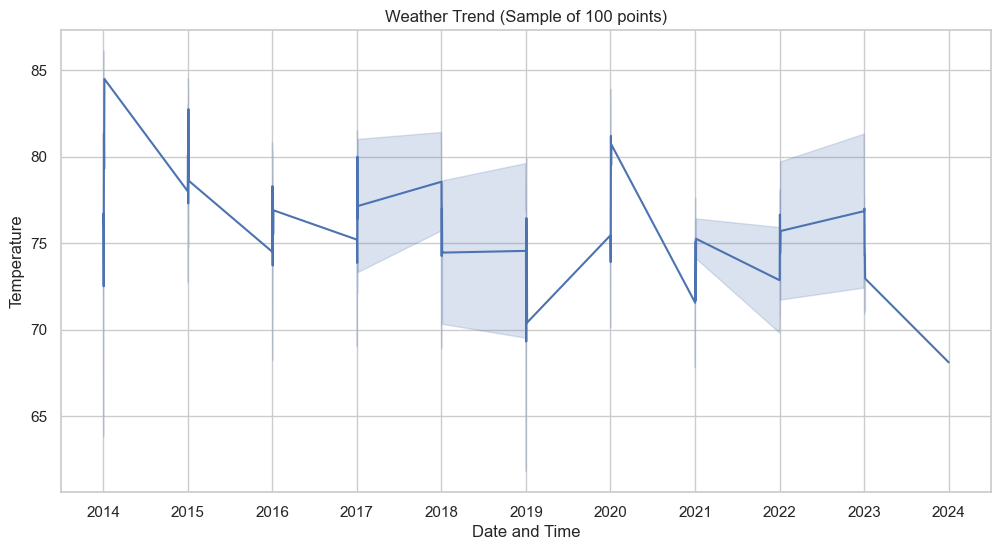


Plotting GPS data...


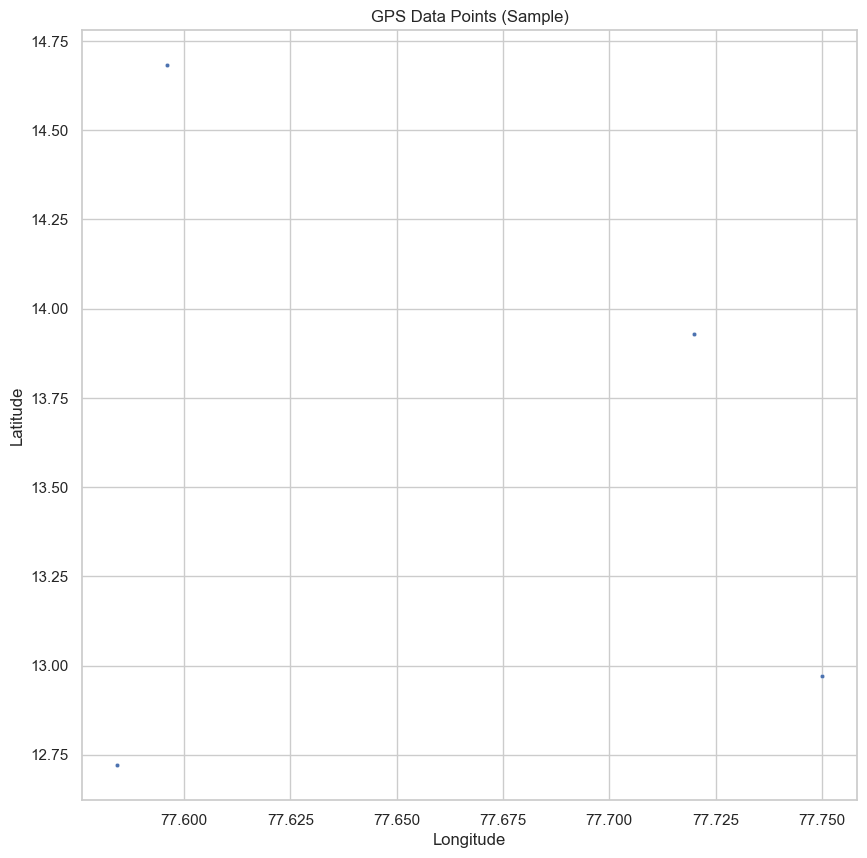


Plotting KSRTC data...


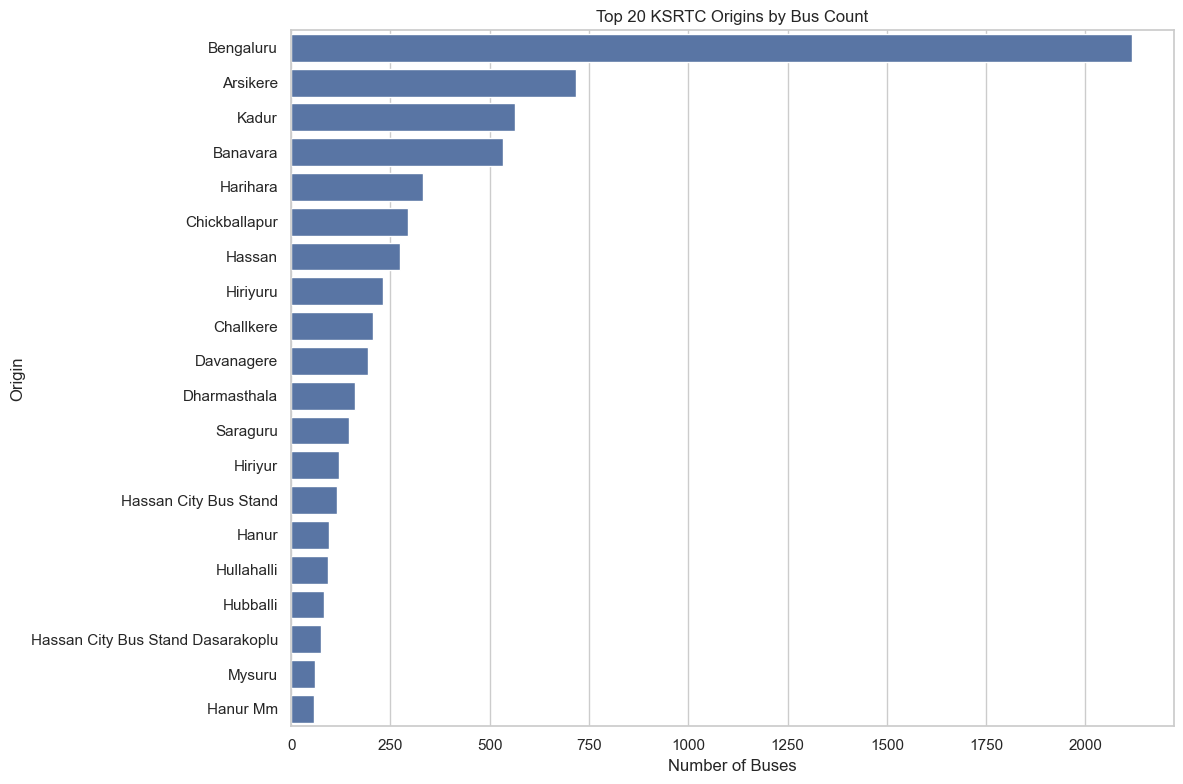


✅ Plotting complete. Graphs have been shown.
Stopping Spark session...


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# It's good practice to wrap your main logic in a function
def main():
    # --- 1. INITIALIZE SPARK ---
    spark = SparkSession.builder \
        .appName("KSRTC_Data_Collection_With_Plots") \
        .getOrCreate()

    # Define base path to avoid repeating long strings
    base_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\DATASETS\\"

    # --- 2. DATA LOADING ---
    print("Starting data loading...")

    # Step 3 - Load Ticketing Data (CSV)
    ticketing_df = spark.read.csv(
        f"{base_path}Ticket_Booking_Franchisee_Counters_in_Karnataka_outside_Bangalore.csv",
        header=True,
        inferSchema=True
    )

    # Step 4 - Load Scheduling Data (CSV)
    schedules_df = spark.read.csv(
        f"{base_path}scheduling.csv",
        header=True,
        inferSchema=True
    )

    # Step 5 - Load Traffic Data (CSV)
    traffic_df = spark.read.csv(
        f"{base_path}Banglore_traffic_Dataset.csv",
        header=True,
        inferSchema=True
    )

    # Step 6 - Load Weather Data (CSV)
    weather_df = spark.read.csv(
        f"{base_path}Bangalore Weather Data (Visual Crossing Weather).csv",
        header=True,
        inferSchema=True
    )

    # Step 7 - Load KSRTC Data (CSV)
    # Note: I moved KSRTC load up to group it with other working loads
    ksrtc_df = spark.read.csv([
        f"{base_path}KSRTC\\csv\\All_Bus_Timetables_Merged_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\ALUR_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\ARSIKERE_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\BANAVARA_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\BengaluruKempegowda_CLEAN.csv",
        f"{base_path}KSRTC\\csv\\Big_Batches_Clean_Audit.csv",
        f"{base_path}KSRTC\\csv\\Bus_Timetables_Batch2_Merged_CLEAN.csv",
        # ... (rest of your KSRTC files) ...
        f"{base_path}KSRTC\\csv\\Clean_Audit_Summary.csv",
        f"{base_path}KSRTC\\csv\\New_Batches_Clean_Audit.csv"
    ],
        header=True,
        inferSchema=True
    )

    # --- 2b. FIX BROKEN GPS DATA LOAD ---
    print("Fixing broken GPS.csv load...")
    try:
        # The schema showed gps.csv was not parsed correctly.
        # We will read it as a raw text file and parse it manually.
        gps_raw_df = spark.read.text(f"{base_path}gps.csv")
        
        # Get the header line (the first row)
        header_str = gps_raw_df.first()[0]
        col_names = header_str.split(',')
        
        # Filter out the header row from the data
        gps_data_df = gps_raw_df.filter(F.col("value") != header_str)
        
        # Split the single 'value' column into multiple columns
        split_cols = F.split(F.col("value"), ',')
        
        # Create the new DataFrame with proper columns
        # Dynamically create select expressions: e.g., data[0] as ID, data[1] as Timestamp
        gps_df = gps_data_df.select(
            *[split_cols[i].alias(col_names[i]) for i in range(len(col_names))]
        )
        
        # **Crucial Step:** Cast Latitude and Longitude from string to double for plotting
        gps_df = gps_df.withColumn("Latitude", F.col("Latitude").cast("double")) \
                     .withColumn("Longitude", F.col("Longitude").cast("double"))
        
        print("✅ GPS.csv successfully parsed and fixed.")

    except Exception as e:
        print(f"Error fixing GPS data: {e}. Plotting will likely fail.")
        # Create a dummy DataFrame to prevent later code from crashing
        gps_df = spark.createDataFrame([], "Latitude double, Longitude double")


    print("✅ Data successfully loaded into Spark DataFrames.")

    # --- 3. INSPECT SCHEMAS (To confirm fixes) ---
    print("\n--- Inspecting Schemas (Check these for column names!) ---")
    print("Weather Schema:")
    weather_df.printSchema()
    
    print("KSRTC Schema:")
    ksrtc_df.printSchema()

    print("FIXED GPS Schema:")
    gps_df.printSchema()
    print("-----------------------------------------------------------\n")

    # --- 4. VISUALIZATION EXAMPLES ---
    sns.set_theme(style="whitegrid")

    # === Example 1: Weather Trend (Line Plot) ===
    # FIXED: Using "Date time" and "Temperature"
    try:
        print("Plotting weather data...")
        weather_pd = weather_df.select("Date time", "Temperature") \
                               .orderBy("Date time") \
                               .limit(100) \
                               .toPandas()
        
        # Convert string datetime to a real datetime object for plotting
        # We use the new correct column name "Date time"
        weather_pd["Date time"] = pd.to_datetime(weather_pd["Date time"])

        plt.figure(figsize=(12, 6))
        # Use the correct column names for x and y
        sns.lineplot(data=weather_pd, x="Date time", y="Temperature")
        plt.title('Weather Trend (Sample of 100 points)')
        plt.ylabel('Temperature')
        plt.xlabel('Date and Time')
        # plt.savefig('weather_trend.png') # Removed as requested
        plt.show() 

    except Exception as e:
        print(f"Could not plot weather data. Error: {e}")

    # === Example 2: GPS Data (Scatter Plot) ===
    # FIXED: Using "Latitude" and "Longitude" from our manually-parsed DataFrame
    try:
        print("\nPlotting GPS data...")
        gps_sample_pd = gps_df.select("Latitude", "Longitude") \
                              .sample(withReplacement=False, fraction=0.01, seed=42) \
                              .limit(2000) \
                              .toPandas()

        plt.figure(figsize=(10, 10))
        # Use the correct column names "Longitude" and "Latitude"
        sns.scatterplot(data=gps_sample_pd, x="Longitude", y="Latitude", s=10)
        plt.title('GPS Data Points (Sample)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        # plt.savefig('gps_scatter.png') # Removed as requested
        plt.show() 

    except Exception as e:
        print(f"Could not plot GPS data. Error: {e}")

    # === Example 3: KSRTC Routes (Bar Plot) ===
    # FIXED: Using "Origin" instead of "Depot_Name"
    try:
        print("\nPlotting KSRTC data...")
        # Use "Origin" as it exists in your schema
        depot_counts = ksrtc_df.groupBy("Origin") \
                               .count() \
                               .orderBy(F.col("count").desc()) \
                               .limit(20) # Get Top 20
        
        depot_counts_pd = depot_counts.toPandas()

        plt.figure(figsize=(12, 8))
        # Use the correct column name "Origin" for y-axis
        sns.barplot(data=depot_counts_pd, y="Origin", x="count", orient='h')
        plt.title('Top 20 KSRTC Origins by Bus Count')
        plt.xlabel('Number of Buses')
        plt.ylabel('Origin')
        plt.tight_layout()
        # plt.savefig('ksrtc_depots.png') # Removed as requested
        plt.show()

    except Exception as e:
        print(f"Could not plot KSRTC data. Error: {e}")

    print("\n✅ Plotting complete. Graphs have been shown.")
    
    # --- 5. Stop Spark ---
    print("Stopping Spark session...")
    spark.stop()

# Run the main function
if __name__ == "__main__":
    main()
